In [1]:
!pip install pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/44/a0/97a6339859d4acb2536efb24feb6708e82f7d33b2ed7e036f2983fcced82/pandas-3.0.2-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/6f/d3/a4bbc01c237ab710a1f22b4da72f4ff6d77eb4c7735ea9811a94ae239067/matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/52.8 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.8 kB ? eta -:--:--
     ---------------------- --------------- 30.7/52.8 kB 660.6 kB/s eta 0:00:01
     -------------------------------------- 52.8/52.8 kB 546.1 kB/s eta 0:00:00
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metad

DEPRECATION: Loading egg at c:\program files\python311\lib\site-packages\vboxapi-1.0-py3.11.egg is deprecated. pip 23.3 will enforce this behaviour change. A possible replacement is to use pip for package installation..

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("customers.csv")
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,PurchaseFrequency
0,1,Male,19,15,39,12
1,2,Male,21,15,81,18
2,3,Female,20,16,6,3
3,4,Female,23,16,77,15
4,5,Female,31,17,40,8


In [6]:
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,PurchaseFrequency
0,1,0,19,15,39,12
1,2,0,21,15,81,18
2,3,1,20,16,6,3
3,4,1,23,16,77,15
4,5,1,31,17,40,8


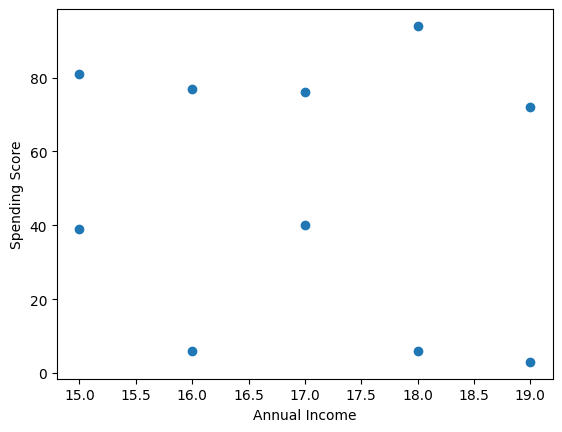

In [7]:
plt.scatter(df['AnnualIncome'], df['SpendingScore'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [8]:
from sklearn.cluster import KMeans

X = df[['AnnualIncome', 'SpendingScore']]

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,PurchaseFrequency,Cluster
0,1,0,19,15,39,12,2
1,2,0,21,15,81,18,0
2,3,1,20,16,6,3,1
3,4,1,23,16,77,15,0
4,5,1,31,17,40,8,2


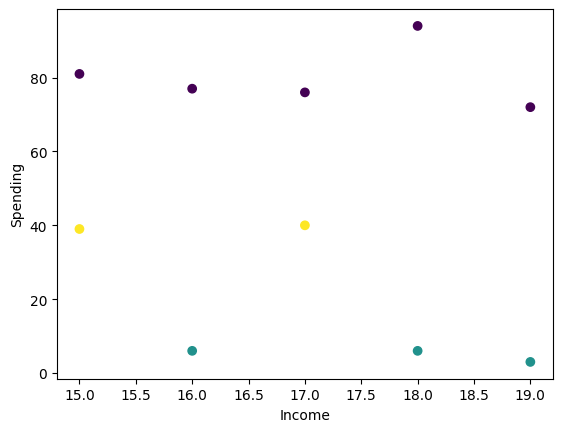

In [9]:
plt.scatter(df['AnnualIncome'], df['SpendingScore'], c=df['Cluster'])
plt.xlabel("Income")
plt.ylabel("Spending")
plt.show()

In [10]:
df.groupby('Cluster').mean()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore,PurchaseFrequency
Cluster,,,,,,
0,6.000000,0.800000,23.800000,17.000000,80.0,16.6
1,6.333333,0.666667,39.666667,17.666667,5.0,2.0
2,3.000000,0.500000,25.000000,16.000000,39.5,10.0


In [11]:
df.to_csv("segmented_customers.csv", index=False)